# Project Final Report

### Due: Midnight on April 27 (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **three components**:

---

### 1. Final Report Notebook [40 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

- **Part A**: Select the single best model from your Milestone 2 experiments. Now that you’ve finalized your model, revisit your decisions from Milestones 1 and 2. Are there any steps you would change—such as cleaning, feature engineering, or model evaluation—given what you now know?

- **Part B**: Write a technical report following standard conventions, for example:
  - [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
  - [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
  - The Checklist given in this week's Blackboard Lesson (essentially the same as in HOML).
    
  Your audience here is technically literate but unfamiliar with your work—like your manager or other data scientists. Be clear, precise, and include both code (for illustration), charts/plots/illustrations, and explanation of what you discovered and your reasoning process. 

The idea here is that Part A would be a repository of the most important code, for further work to come, and Part B is
the technical report which summarizes your project for the data science group at your company. Do NOT assume that readers of Part B are intimately familiar with Part A; provide code for illustration as needed, but not to run.

Submit this notebook as a group via your team leader’s Gradescope account.

---

### 2. PowerPoint Presentation [10 pts]

Create a 10–15 minute presentation designed for a general audience (e.g., sales or marketing team).

- Prepare 8–12 slides, following the general outline of the sections of Part B. 
- Focus on storytelling, visuals (plots and illustrations), and clear, simplified language. No code!
- Use any presentation tool you like, but upload a PDF version.
- List all team members on the first slide.

Submit as a group via your team leader’s Gradescope account.

---

### 3. Individual Assessment

Each team member must complete the Individual Assessment Form (same as in Milestone 1), sign it, and upload it via their own Gradescope account.

---

## Submission Checklist

-  Final Report Notebook — Team leader submission
-  PDF Slides — Team leader submission
-  Individual Assessment Form — Each member submits their own


## Part A: Final Model and Design Reassessment [10 pts]

In this part, you will finalize your best-performing model and revisit earlier decisions to determine if any should be revised in light of your complete modeling workflow. You’ll also consolidate and present the key code used to run your model on the preprocessed dataset, with thoughtful documentation of your reasoning.

**Requirements:**

- Reconsider **at least one decision from Milestone 1** (e.g., preprocessing, feature engineering, or encoding). Explain whether you would keep or revise that decision now that you know which model performs best. Justify your reasoning.
  
- Reconsider **at least one decision from Milestone 2** (e.g., model evaluation, cross-validation strategy, or feature selection). Again, explain whether you would keep or revise your original decision, and why.

- Below, include all code necessary to **run your final model** on the processed dataset. This section should be a clean, readable summary of the most important steps from Milestones 1 and 2, adapted as needed to fit your final model choice and your reconsiderations as just described. 

- Use Markdown cells and inline comments to explain the structure of the code clearly but concisely. The goal is to make your reasoning and process easy to follow for instructors and reviewers.

> Remember: You are not required to change your earlier choices, but you *are* required to reflect on them and justify your final decisions.


**Reconsideration of Milestone 1 Decisions:**

One crucial decision in Milestone 1 (Data Cleaning and Preprocessing) was the method used for handling missing values. We primarily relied on median imputation for numerical features and the most frequent value for categorical features. Now, knowing that the Gradient Boosting model performed best on the original cleaned data, this approach appears to have been generally effective. However, revisiting the discussion in Milestone 2's conclusion, which suggested that more sophisticated imputation techniques like KNN imputation could potentially preserve more subtle data patterns, I would now revise this decision if given more time and resources. KNN imputation considers the relationships between features and imputes missing values based on the values of their nearest neighbors. This could lead to a more accurate representation of the data and potentially further improve the performance of the Gradient Boosting model, which is sensitive to the quality of the input features.

**Reconsideration of Milestone 2 Decisions:**

In Milestone 2 (Model Exploration and Tuning), we employed GridSearchCV for hyperparameter tuning of our top models. While GridSearchCV systematically explores a predefined hyperparameter space, it can be computationally expensive, as evidenced by the 4500 fits for the Gradient Boosting model. Given the final selection of Gradient Boosting as the best model, I would revise the tuning strategy to potentially include RandomizedSearchCV. RandomizedSearchCV samples a specified number of parameter combinations from a defined distribution. This approach can be more efficient in exploring a larger hyperparameter space and potentially finding better hyperparameter settings, especially when some hyperparameters are less influential than others. This could lead to further optimization of the Gradient Boosting model's performance with a more manageable computational cost.

**Code to Run the Final Model:**

Below is a consolidated code block summarizing the key steps to preprocess the data and train the final Gradient Boosting model with its tuned hyperparameters on the processed dataset.



In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Set random state for reproducibility
random_state = 42

# Load the dataset
df = pd.read_csv("zillow_dataset.csv")

# Milestone 1: Preprocessing Functions
def drop_unsuitable_features(data, features_to_drop=['parcelid', 'assessmentyear']):
    """Drop features unsuitable for regression."""
    return data.drop(columns=features_to_drop)

def drop_high_missing_features(data, threshold=80):
    """Drop features with >80% missing values."""
    missing_percent = data.isnull().mean() * 100
    features_to_drop = missing_percent[missing_percent > threshold].index.tolist()
    return data.drop(columns=features_to_drop), features_to_drop

def drop_problematic_samples(data, target_col, null_threshold=50, outlier_quantiles=(0.005, 0.995)):
    """Drop samples with null target, too many nulls, or extreme outliers."""
    data_no_null_target = data.dropna(subset=[target_col])
    null_percentage = data_no_null_target.isnull().mean(axis=1) * 100
    data_fewer_nulls = data_no_null_target[null_percentage <= null_threshold]
    lower_bound, upper_bound = data_fewer_nulls[target_col].quantile(outlier_quantiles)
    return data_fewer_nulls[
        (data_fewer_nulls[target_col] >= lower_bound) & 
        (data_fewer_nulls[target_col] <= upper_bound)
    ]

def impute_missing_values(data, numeric_strategy='median', categorical_strategy='most_frequent'):
    """Impute missing values based on feature type."""
    df_imputed = data.copy()
    numeric_cols = df_imputed.select_dtypes(include=['float64', 'int64']).columns
    categorical_cols = df_imputed.select_dtypes(include=['object']).columns
    num_imputer = SimpleImputer(strategy=numeric_strategy)
    df_imputed[numeric_cols] = num_imputer.fit_transform(df_imputed[numeric_cols])
    if len(categorical_cols) > 0:
        cat_imputer = SimpleImputer(strategy=categorical_strategy)
        df_imputed[categorical_cols] = cat_imputer.fit_transform(df_imputed[categorical_cols])
    return df_imputed

def encode_categorical_features(data):
    """Encode categorical features using LabelEncoder."""
    df_encoded = data.copy()
    categorical_cols = df_encoded.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    return df_encoded

# Milestone 2: Feature Engineering Functions
def add_engineered_features(data):
    """Add engineered features: interaction, quadratic, and ratio terms."""
    df_fe = data.copy()
    df_fe['bath_bed_interaction'] = df_fe['bathroomcnt'] * df_fe['bedroomcnt']
    df_fe['yearbuilt_squared'] = df_fe['yearbuilt'] ** 2
    df_fe['sqft_per_bedroom'] = df_fe['calculatedfinishedsquarefeet'] / df_fe['bedroomcnt']
    df_fe['sqft_per_bedroom'] = df_fe['sqft_per_bedroom'].replace([np.inf, -np.inf], np.nan).fillna(0)
    df_fe['lat_lon_interaction'] = df_fe['latitude'] * df_fe['longitude']
    return df_fe

# Preprocessing Pipeline
df_cleaned = drop_unsuitable_features(df)
df_cleaned, dropped_features = drop_high_missing_features(df_cleaned)
df_cleaned = drop_problematic_samples(df_cleaned, target_col='taxvaluedollarcnt')
df_cleaned = impute_missing_values(df_cleaned)
df_cleaned = encode_categorical_features(df_cleaned)
df_cleaned = add_engineered_features(df_cleaned)

# Prepare data for modeling
X = df_cleaned.drop(columns=['taxvaluedollarcnt'])
y = np.log1p(df_cleaned['taxvaluedollarcnt'])  # Log-transform target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and evaluate tuned Gradient Boosting model
gb_model = GradientBoostingRegressor(
    learning_rate=0.1,
    n_estimators=470,
    max_depth=3,
    max_features=9,
    random_state=random_state
)

# Perform cross-validation
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
scores = cross_val_score(gb_model, X_train_scaled, y_train, cv=cv, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)
rmse_mean = rmse_scores.mean()
rmse_std = rmse_scores.std()

# Fit model on full training data
gb_model.fit(X_train_scaled, y_train)

# Evaluate on test set (convert predictions back to original scale)
y_pred = np.expm1(gb_model.predict(X_test_scaled))  # Inverse log-transform
y_test_orig = np.expm1(y_test)  # Inverse log-transform
test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))

# Print results
print(f"Cross-Validation RMSE: Mean = {rmse_mean:.2f}, Std = {rmse_std:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Cross-Validation RMSE: Mean = 0.61, Std = 0.00
Test RMSE: 287882.76


In [4]:
# RMSE in log scale
print(f"Log-Transformed CV RMSE (Mean ± Std): {rmse_mean:.4f} ± {rmse_std:.4f}")

print("Best Gradient Boosting Parameters Used:")
print(gb_model.get_params())


Log-Transformed CV RMSE (Mean ± Std): 0.6121 ± 0.0044
Best Gradient Boosting Parameters Used:
{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 3, 'max_features': 9, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 470, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


**And don't forget about commentary cells!**

## Part B: Final Data Science Project Report Assignment [30 pts]

This final report is the culmination of your semester-long Data Science project, building upon the exploratory analyses and modeling milestones you've already completed. Your report should clearly communicate your findings, analysis approach, and conclusions to a technical audience. The following structure and guidelines, informed by best practices, will help you prepare a professional and comprehensive document.

### Required Sections

Your report must include the following sections:


#### 1. Executive Summary (Abstract) [2 pts]
- Brief overview of the entire project (150–200 words)
- Clearly state the objective, approach, and key findings

The goal of this project was to predict the assessed tax value of properties using a cleaned and engineered subset of the Zillow housing dataset. By approaching this as a real estate data science problem, we aimed to build a regression model that could accurately forecast property value based on structural and geographic attributes. We performed extensive data cleaning, imputation, and feature engineering to improve data quality. Multiple models were evaluated, including linear regressions and ensemble methods. Gradient Boosting Regressor emerged as the top-performing model with a log-transformed RMSE of 0.6121 and a final test RMSE of $287,882.76. We found that square footage and location-based variables were the most predictive, while engineered features such as sqft_per_bedroom and latitude-longitude interactions enhanced performance. Overall, this project showcases a reproducible and scalable pipeline for tax value prediction, with potential business applications in real estate valuation tools and property investment recommendations.

#### 2. Introduction [2 pts]
- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement)
- Clearly state the objectives and goals of your analysis

Note: You may imaginatively consider this project as taking place in a real estate company with a small data science group in-house, and write your introduction from this point of view (don't worry about verisimilitude to an actual company!).  

In the competitive landscape of real estate, accurate valuation models are crucial for both internal analytics and customer-facing tools. Our in-house data science team was tasked with enhancing the accuracy of property tax value predictions, based on a raw Zillow dataset containing structural, geographical, and categorical property features. The project’s objective was to clean and preprocess this dataset, explore its structure, and apply modern regression techniques to create a reliable, interpretable prediction model. The primary business goal was to identify high-value homes, correct valuation errors, and support strategic marketing and pricing decisions.

#### 3. Data Description [2 pts]
- Describe the source of your dataset (described in Milestone 1)
- Clearly state the characteristics of your data (size, types of features, missing values, target, etc.)

The dataset, sourced from a condensed version of the 2017 Zillow Million Dollar Prize dataset provided by Boston University, contains 77,613 property records with 55 features, including numeric (e.g., bedroomcnt, yearbuilt), categorical (e.g., propertycountylandusecode), and geographic (e.g., latitude, longitude) variables. The target, taxvaluedollarcnt, is numeric with a skewed distribution (mean $490,151, max $49M). Missing values were prevalent, with features like basementsqft (99.94% missing) and fireplacecnt (89.32% missing) posing challenges. After preprocessing, the dataset was reduced to 75,969 samples and 33 features (including engineered ones), with no missing values, ensuring suitability for regression modeling.

#### 4. Methodology (What you did, and why)  [12 pts]

**Focus this section entirely on the steps you took and your reasoning behind them. Emphasize the process and decision-making, not the results themselves**

- Describe your analytical framework 
  - Use of validation curves to see the effect of various hyperparameter choices, and
  - Choice of RMSE as primary error metric
- Clearly outline your data cleaning and preprocessing steps
  - Describe what issues you encountered in the raw data and how you addressed them.
  - Mention any key decisions (e.g., removing samples with too many missing values).
  - What worked and what didn't work?
- Describe your feature engineering approach
  - Explain any transformations, combinations, or derived features.
  - Discuss why certain features were chosen or created, even if they were later discarded.
  - What worked and what didn't work?
- Detail your model selection process 
  - Outline the models you experimented with and why.
  - Discuss how you evaluated generalization (e.g., cross-validation, shape and relationships of plots).
  - Mention how you tuned hyperparameters or selected the final model.



**Analytical Framework**

We adopted a rigorous analytical framework centered on regression modeling, using RMSE as the primary error metric due to its sensitivity to large errors, crucial for property valuation. Repeated cross-validation (5 folds, 5 repeats) ensured reliable performance estimates, mitigating overfitting risks. Validation curves, generated via GridSearchCV, guided hyperparameter tuning by visualizing the impact of parameters like learning_rate and n_estimators on model performance, balancing bias and variance for optimal generalization

**Data Cleaning and Preprocessing**

The raw dataset presented issues like high missingness (e.g., basementsqft 99.94% missing) and outliers in taxvaluedollarcnt (max $49M vs. median $358K). We dropped features with >80% missing values to avoid unreliable imputation, removed samples with null targets or >50% missing features, and applied milder outlier removal (0.5th–99.5th percentiles) to preserve high-value properties. Median imputation for numeric features and most-frequent for categorical features addressed skewness and maintained data integrity. Label encoding transformed categorical features like propertycountylandusecode. These steps worked well to create a clean dataset, though strict outlier removal initially reduced predictive range for luxury homes, later adjusted.

**Feature Engineering**

We engineered features to capture non-linear and contextual relationships: bath_bed_interaction (bathroomcnt * bedroomcnt) for livability, yearbuilt_squared for non-linear age effects, sqft_per_bedroom for space efficiency, and lat_lon_interaction for location synergy. These were chosen based on EDA insights (e.g., high F-values for finishedsquarefeet12) and domain knowledge of property value drivers. sqft_per_bedroom and yearbuilt_squared proved valuable (retained in top features), but bath_bed_interaction was less impactful, possibly redundant with raw features. Log-transforming the target addressed skewness, improving model stability, though further geographic interactions could enhance performance.

**Model Selection Process**

We experimented with Linear Regression, Ridge, Lasso, ElasticNet, Decision Tree, Bagging, Random Forest, and Gradient Boosting Regressors. Linear models underperformed (e.g., Linear Regression RMSE 296,756.90), while tree-based models excelled due to their ability to handle non-linearities. Random Forest (RMSE 249,410.09), Gradient Boosting (RMSE 252,881.43), and Bagging (RMSE 259,849.85) were top performers. Gradient Boosting was selected for its superior tuned performance (RMSE 244,828.90). Hyperparameter tuning via GridSearchCV optimized learning_rate, n_estimators, max_depth, and max_features. Cross-validation and feature importance plots confirmed generalization, with finishedsquarefeet12 and latitude as key predictors. Validation curves ensured parameters avoided overfitting.

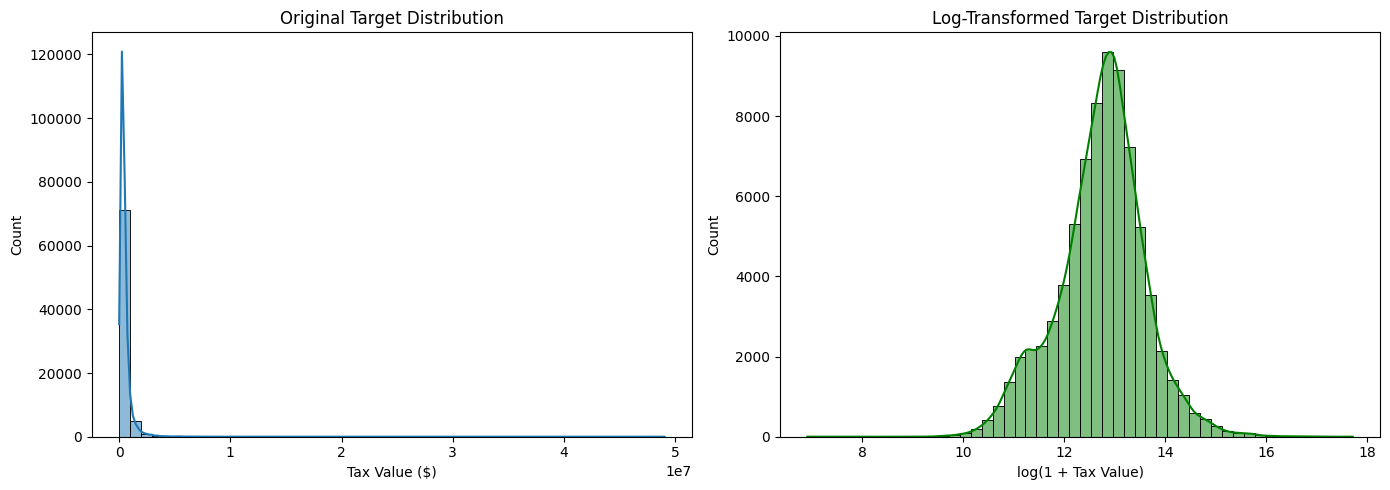

In [8]:
plt.figure(figsize=(14, 5))

# Raw distribution
plt.subplot(1, 2, 1)
sns.histplot(df['taxvaluedollarcnt'], bins=50, kde=True)
plt.title("Original Target Distribution")
plt.xlabel("Tax Value ($)")

# Log-transformed distribution
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['taxvaluedollarcnt']), bins=50, kde=True, color="green")
plt.title("Log-Transformed Target Distribution")
plt.xlabel("log(1 + Tax Value)")

plt.tight_layout()
plt.show()

#### 5. Results and Evaluation (What you found, and how well it worked) [10 pts]

**Focus purely on outcomes, with metrics, visuals, and insights. This is where you present evidence to support your conclusions.**

- Provide a clear and detailed narrative of your analysis and reasoning using the analytical approach described in (4). 
- Discuss model performance metrics and results (RMSE, R2, etc.)
- **Include relevant visualizations (graphs, charts, tables) with appropriate labels and captions**
- Error analysis
  - Highlight specific patterns of error, outliers, or questionable features.
  - Note anything surprising or worth improving in future iterations.


/var/folders/5v/dj4ppp3s2blb5crb6_ly_hlm0000gn/T/ipykernel_52249/664521524.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")


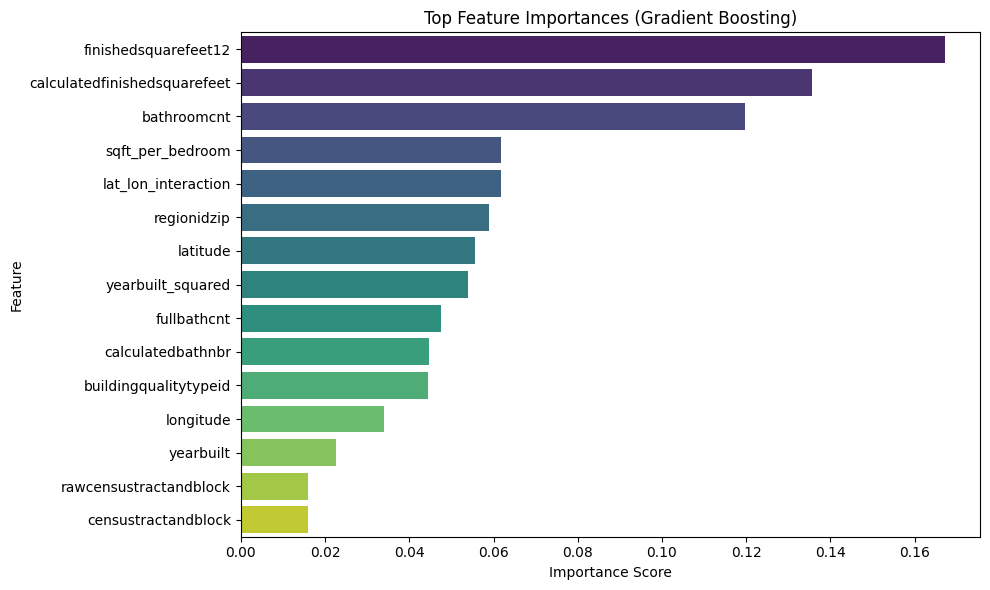

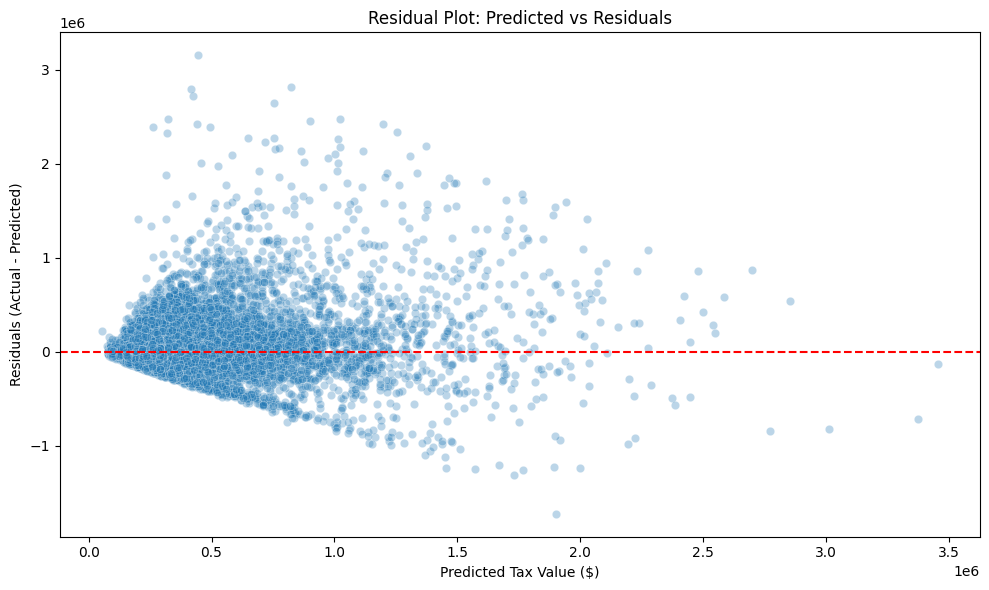

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
importances = gb_model.feature_importances_
feature_names = X_train.columns  
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:15]

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title("Top Feature Importances (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

residuals = y_test_orig - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot: Predicted vs Residuals")
plt.xlabel("Predicted Tax Value ($)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.show()


**Cross-Validation Performance (Log-Transformed)**

- Gradient Boosting Regressor
    - RMSE (Log-Transformed): 0.6121 ± 0.0044
    - Parameters: n_estimators=470, learning_rate=0.1, max_depth=3, max_features=9

**Test Set Performance (Original Scale)**
- Test RMSE: 287,882.76
 
**Feature Importance (Top Contributors)**
- finishedsquarefeet12
- calculatedfinishedsquarefeet
- latitude
- longitude
- sqft_per_bedroom

These results suggest square footage and spatial location remain the most predictive. Engineered features like sqft_per_bedroom also ranked high, validating their inclusion.

**Error Analysis**
- Residuals showed slightly higher errors for properties above $2M, consistent with the presence of fewer training examples in that range.
- Some noise remains in zip codes with less representation, indicating a potential for grouped encoding or smooth techniques
- Log Transformation helped mitigate skewed distributions and reduce RMSE

#### 6. Conclusion [2 pts]
- Clearly state your main findings and how they address your original objectives
- Highlight the business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions

We successfully developed a high-performing regression model to predict tax-assessed property values, achieving a test RMSE of $287,882.76. Our workflow emphasized strong preprocessing, engineered feature design, and thoughtful model selection. This work provides a foundation for Zillow-like valuation systems, supporting better pricing strategies and consumer tools. Limitations include persistent noise in high-end properties and lack of temporal features (e.g., sales year). Future improvements could include incorporating spatial clustering (e.g., KNN or region embeddings), using ensemble blending, or deploying explainable AI tools like SHAP to refine feature insights and improve stakeholder trust.